Bayesian full moment-tensor inversion for a synthetic scenario of the DPRK 2013 event. 
Random noise is added to the synthetic data, with a known standard deviation estimated
from pre-event noise. The Earth model uncertainty is introduced by using a different 
Earth model to do the inversion, and this uncertainty is treated by station-specific time-shifts.


In [1]:
import os
import numpy as np

from mtuq import read, open_db
from mtuq.event import Origin
from mtuq.graphics import plot_data_greens1, plot_beachball
from mtuq.misfit import Misfit
from mtuq.process_data import ProcessData
from mtuq.util.cap import parse_station_codes

import multiprocessing as mp
from hibasin.misfit.likelihood import MCMC_FullMij
from hibasin.util.covariance_matrix_Cd import covariance_matrix_Cd
from hibasin.util.covariance_matrix_Cm import covariance_matrix_Cm
from hibasin.misfit.misfit_preparation import shift_greens
from hibasin.visualization.plot_waveform_fit import plot_waveform_fit
from hibasin.visualization.plot_posterior import (
    posterior_distribution_mij,
    posterior_distribution_noise,
    posterior_distribution_timeshift
)
from hibasin.misfit.misfit_preparation import to_numpy_arrays
from hibasin.util.math import ned2rtp
from obspy.signal.filter import bandpass
from mtuq.util.cap import taper
import matplotlib.pyplot as plt

os.environ["OMP_NUM_THREADS"] = "1"
mp.set_start_method("fork", force=True)


# Generate synthetic dataset
## step 1: load the pre-computed Green's functions and observations. 
The observations are used to estimate a pre-event noise strength to generate similar level noise for random noise.
The simulated random noise is added to the synthetics

In [2]:
# Paths
# ------------------------------------------------------------------
path_data      = '../data/20130212025751000/*.BH[ZRT].sac'
path_weights   = '../data/20130212025751000/weights_surf.dat'
event_id       = '20130212025751000'

# This Green's funtions (GF) database is calculated using a perturbed model from mdj3,
# called mod100 here to represent the true Earth model. You can use another choice among all perturbed models
gf_database_true = '/Users/u7091895/Documents/Research/Tutorials/hibasin_cps/mod100/'
# Note: The GF database here is for a composite models in which each station has its own 1D model
# So, I manually copy the GFs for each station into a folder 'mod100' for using MTUQ to read them. 
# It is to mimic the 1D model case.
# All station-specific models are in folder ../data/velmod2d/

# This GF database is for a reference model (mdj) which represents our imperfect Earth model. 
# This model should be fix.
gf_database_inv = '../data/grn_2013_2d/mdj3/'

# ------------------------------------------------------------------
# Processing to generate the 'observations'
# ------------------------------------------------------------------
process_sw = ProcessData(
    filter_type='Bandpass',
    freq_min=0.02,
    freq_max=0.05,
    pick_type='CPS_metadata',
    CPS_database=gf_database_true,
    window_type='surface_wave',
    window_length=350,
    capuaf_file=path_weights,
    apply_scaling=False,
)

misfit_sw = Misfit(
    norm='L2',
    time_shift_min=-10.,
    time_shift_max=+10.,
    time_shift_groups=['ZR', 'T'],
)

station_id_list = parse_station_codes(path_weights)

origin = Origin({
    'time':       '2013-02-12T02:57:51.272500Z',
    'latitude':   41.2921,
    'longitude':  129.0730,
    'depth_in_m': 500.,
})
evdp_in_km = origin.depth_in_m / 1000

# a scale factor for Mij and GFs
M00 = 1.e14

print('Reading data...\n')
data = read(path_data, format='sac',
            event_id=event_id,
            station_id_list=station_id_list,
            tags=['units:m', 'type:displacement'])
data.sort_by_distance()
stations = data.get_stations()

print('Processing data...\n')
data_sw = data.map(process_sw)

print('Reading Greens functions for generating observations...\n')
db = open_db(gf_database_true, 
             format='CPS', model='mod100')
greens = db.get_greens_tensors(stations, origin)

print('Processing Greens functions...\n')
greens_sw = greens.map(process_sw)

#downsampling the data and gfs for efficicency
for s in range(len(stations)):
    data_sw[s].resample(1.0)
    greens_sw[s].resample(1.0)
    data_sw[s].station._refresh('delta', 1)
    greens_sw[s].station._refresh('delta', 1)

print('Estimating noise standard deviation...\n')
data_noise = read(path_data, format='sac',
                  event_id=event_id,
                  station_id_list=station_id_list,
                  tags=['units:m', 'type:displacement'])
data_noise.sort_by_distance()
for traces in data_noise:
    traces.resample(1.0)
    traces.station._refresh('delta', 1)

npts_acf_lag = data_sw[0][0].stats.npts

noise_estimator = covariance_matrix_Cd(
    origin, data_noise, npts_acf_lag, process_sw,
    noise_length=1600,
    noise_model='uncorrelated',
)
noise_std_sw = noise_estimator.get_noise_std()   # (ns, nc)
print(f'  noise_std shape: {noise_std_sw.shape}\n')

/Users/u7091895/Documents/Research/Tutorials/hibasin_cps/mod100/
/Users/u7091895/Documents/Research/Tutorials/hibasin_cps/mod100/
Reading data...

Processing data...

Reading Greens functions for generating observations...

Processing Greens functions...

Estimating noise standard deviation...

  noise_std shape: (5, 3)



## Step 2: Generate observations based on the given moment tensor parameters and Green's functions

(5, 3, 6, 350)
The upper bound of VR could be 95.5%


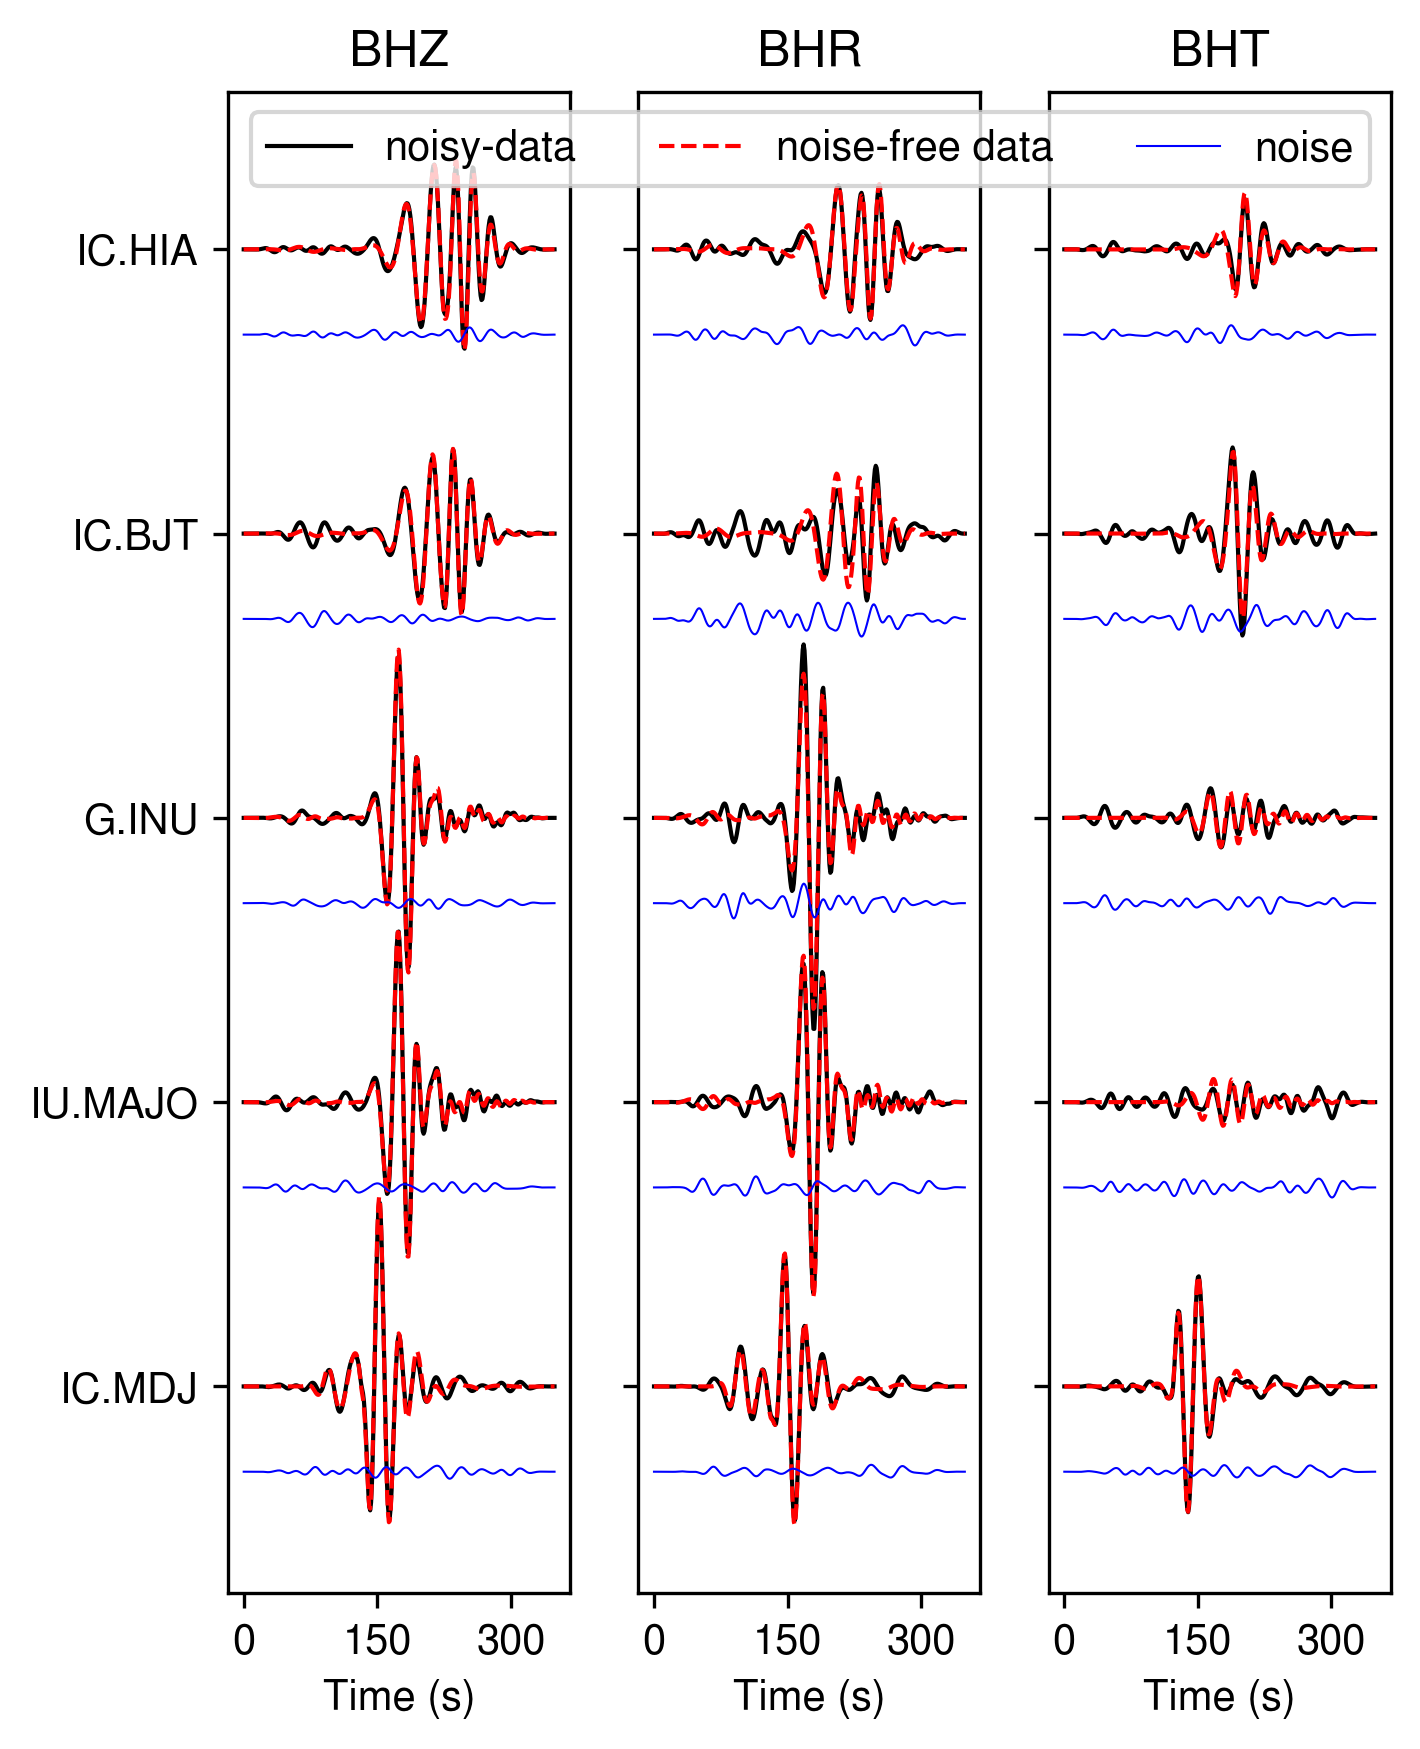

In [6]:
##Simulate the new 'observatations' with a given explosive-like MT

#collapse the Data structure in mtuq to numpy array
data_sw_array, greens_sw_array,_ = to_numpy_arrays(data_sw, greens_sw)
ns,nc,ne,nt = greens_sw_array.shape
print(greens_sw_array.shape)

#Give an ISO-dominainting source in the up-south-east convention
mij_true = ned2rtp(np.array([22.74, 30.00, 8.77, -9.13, -3.72, -6.22])) * M00

#d=Gm to get noise-free waveforms
syn_data = np.einsum('scet,e->sct', greens_sw_array, mij_true)


#plot the waveform before and after adding noise
fig,ax = plt.subplots(1,3, figsize=(5,6.5), sharex=True, sharey=True)
comp_title = ['BHZ','BHR','BHT']

max_amp = 1.5*np.max(syn_data)
np.random.seed(4000)
for s in range(ns):
    for c in range(nc):

        #generate a uncorrelated data noise series based on the ambient noise level
        noise = np.random.normal(0, 1, nt)
        #the same filter as for the waveforms
        noise = bandpass(noise, freqmin=0.02, freqmax=0.05, df=1.0) 
        taper(noise, taper_fraction=0.2)
        d_rms = np.sqrt(np.mean(np.square(noise)))
        noise = noise/d_rms * noise_std_sw[s,c]

        ##we set the noise level is 1.5 times ambient noise level here
        tmp = syn_data[s,c] + 1.5*noise
        
        #plot
        ax[c].plot(tmp/max_amp+s, 'k',lw=1, label='noisy-data')
        ax[c].plot(syn_data[s,c]/max_amp+s, 'r', linestyle='dashed',lw=1, label='noise-free data')
        ax[c].plot(noise/max_amp+s-0.3, 'blue',lw=.5, label='noise')
        ax[c].set_xticks([0,150,300])
        ax[c].set_xlabel('Time (s)')
        ax[c].set_yticks(np.arange(ns))
        ax[c].set_yticklabels([s.network + '.' + s.station for s in stations])
        ax[c].set_title(comp_title[c])
        
        #replace the data with new syn data. data_sw will be used for inversion later
        data_sw[s].select(channel=comp_title[c])[0].data = tmp
plt.legend(['noisy-data','noise-free data', 'noise'], ncols=3)
plt.savefig('waveform_comparison.jpg', bbox_inches='tight', dpi=300)

##calculate the upper bound of VR
res = data_sw_array - syn_data
vr = (1 - np.sum(res**2)/np.sum(data_sw_array**2)) * 100
print("The upper bound of VR could be %.1f%%" % vr)

# Bayesian inversion by using a different Earth model (mdj3). 
## Trial 1: The inversion includes station-specific noise level parameters (Ground truth is 1.5 for all stations) and time shifts (account for the model uncertainty

In [8]:
tag = 'trial_1'
print('Reading Greens functions for a different model (i.e., mdj3) to do inversion...\n')
db_inv = open_db(gf_database_inv, format='CPS', model='mdj3')
greens_inv = db_inv.get_greens_tensors(stations, origin)

# Must use the mdj3 CPS database for window timing, not mod100
process_sw_inv = ProcessData(
    filter_type='Bandpass',
    freq_min=0.02,
    freq_max=0.05,
    pick_type='CPS_metadata',
    CPS_database=gf_database_inv,
    window_type='surface_wave',
    window_length=350,
    capuaf_file=path_weights,
    apply_scaling=False,
)

print('Processing Greens functions...\n')
greens_sw = greens_inv.map(process_sw_inv)

#downsampling the newly-loaded GFs for efficiency
for s in range(len(stations)):
    greens_sw[s].resample(1.0)
    greens_sw[s].station._refresh('delta', 1)

# ------------------------------------------------------------------
# MCMC for Mij parameters, uncorrelated noise parameters and time shift parameters
# ------------------------------------------------------------------
print('MCMC sampling with uncorrelated noise + timeshift...\n')
np.random.seed(1000)

#number of chains
nwalker = 512
#number of steps for each chain
nsteps  = 5000

solver = MCMC_FullMij(
    misfit_sw, data_sw, greens_sw, noise_std_sw,
    max_noise_parameter=40, M00=M00,
    noise_type='uncorrelated',
)

print('ne-%d, ns-%d, nc-%d, ndim-%d'
      % (solver.ne, solver.ns, solver.nc, solver.ndim))

init = np.random.uniform(-solver.MAXVAL, solver.MAXVAL,
                         (nwalker, solver.ndim))

sampler, pool = solver.get_sampler('emcee', nchains=nwalker)
sampler.run_mcmc(init, nsteps, progress=True)
solver.cleanup(pool)

print(f'Acceptance rate: {100 * np.mean(sampler.acceptance_fraction):.1f}%')
solver.save_chains(sampler, file_path='./', thin=2)

# ------------------------------------------------------------------
# Post-processing and figures
# ------------------------------------------------------------------
source_sol, noise_sol, tau_sol = solver.get_solution(
    sampler, warm_up_steps=int(0.5 * nsteps), thin=100)

print('Best-fit moment tensor:')
print(source_sol.get_dict(0))

print('Generating figures...\n')
best_mt   = source_sol.get(0)
lune_dict = source_sol.get_dict(0)

plot_data_greens1(
    f'{event_id}_waveforms_{tag}_d{evdp_in_km}km.png',
    data_sw, greens_sw, process_sw,
    misfit_sw, stations, origin, best_mt, lune_dict)

plot_beachball(
    f'{event_id}_beachball_{tag}_d{evdp_in_km}km.png',
    best_mt, stations, origin)

plot_waveform_fit(
    best_mt.as_vector(), solver.obs, solver.greens,
    stations, noise_sol, tau_sol,
    f'{event_id}_waveformfit_{tag}.jpg',
    delta=1, evdp_in_km=evdp_in_km)

posterior_distribution_mij(
    flat_samples_fname=solver.chain_fname,
    log_prob_fname=solver.logprob_fname,
    mt_degree=solver.ne, thin=2, ratio=0.5,
    figure_fname=f'{event_id}_posterior_source_{tag}.jpg')

posterior_distribution_noise(
    flat_samples_fname=solver.chain_fname,
    mt_degree=solver.ne, thin=10, ratio=0.5,
    stations=stations,
    figure_fname=f'{event_id}_posterior_noise_{tag}.jpg')

posterior_distribution_timeshift(solver, thin=10, ratio=0.5, stations=stations, 
                                 figure_fname=f'{event_id}_Posterior_timeshift_{tag}.jpg')

print(f'noise_sol : {noise_sol}')
print(f'tau_sol   : {tau_sol}')
print("\nInversion done for trial 1\n")

Reading Greens functions for a different model (i.e., mdj3) to do inversion...

../data/grn_2013_2d/mdj3/
../data/grn_2013_2d/mdj3/
Processing Greens functions...

MCMC sampling with uncorrelated noise + timeshift...

ne-6, ns-5, nc-3, ndim-21
Creating a emcee sampler with chains=512 and ndim=21


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5000/5000 [07:14<00:00, 11.52it/s]


Acceptance rate: 30.4%

Number of quasi-independent samples: 12800
Best-fit moment tensor:
{'rho': 5632092215928644.0, 'v': 0.14067781926349987, 'w': 1.1745649711716841, 'kappa': 74.82727203500471, 'sigma': -46.03747434090704, 'h': 0.20113640468387975}
Generating figures...

(5, 3, 350) (5, 3, 6, 350)
number of samples 640000 and half number is 320000 
mean mt: [ 27.94205658  35.89190091  26.21217474  -9.14822985 -11.04920312
  -1.10335918]
(320000, 6)
mean noise: [1.4927183  1.90525126 1.8975796  1.6969387  1.67958179]
mean timeshifts: [ 0.10021717 -0.26018777  0.83813997  1.04791391  0.82187668  1.78836194
  0.53350156 -0.75702345  0.15261862 -1.27060992]
noise_sol : [1.49280299 1.90525316 1.89671453 1.69683722 1.68056261]
tau_sol   : [ 0.100377   -0.25997728  0.83761414  1.04772236  0.82121195  1.78625089
  0.53317475 -0.7574083   0.1521509  -1.26856392]

Inversion done for trial 1



## Trial 2: The inversion includes station-specific noise level parameters (Ground truth is 1.5 for all stations) and time shifts (account for the model uncertainty

In [11]:
tag = 'trial_2'

# The path for storing the GF ensemble
path_ensemble = '/Users/u7091895/Documents/Research/Tutorials/hibasin_cps/work_5pr/'

## The first step is still to load the GFs
print('Reading Greens functions for a different model (i.e., mdj3) to do inversion...\n')
db_inv = open_db(gf_database_inv, format='CPS', model='mdj3')
greens_inv = db_inv.get_greens_tensors(stations, origin)

# Must use the mdj3 CPS database for window timing, not mod100
process_sw_inv = ProcessData(
    filter_type='Bandpass',
    freq_min=0.02,
    freq_max=0.05,
    pick_type='CPS_metadata',
    CPS_database=gf_database_inv,
    window_type='surface_wave',
    window_length=350,
    capuaf_file=path_weights,
    apply_scaling=False,
)

print('Processing Greens functions...\n')
greens_sw = greens_inv.map(process_sw_inv)

#downsampling the newly-loaded GFs for efficiency
for s in range(len(stations)):
    greens_sw[s].resample(1.0)
    greens_sw[s].station._refresh('delta', 1)

    
# ----------------------------------------------------------------------
# Model-error covariance C_m from pre-computed Green's function ensemble
# ----------------------------------------------------------------------
print('Loading Green\'s function ensemble...\n')

greens_ensemble_by_group = {}
group_station_list       = {}
for sta in stations:
    net_sta  = f'{sta.network}.{sta.station}'
    ens_path = os.path.join(path_ensemble, sta.station,
                            f'{sta.station}_ensemble.npy')
    ens = np.load(ens_path)   # (M, 1, nc, ne, nt)
    greens_ensemble_by_group[net_sta] = ens
    group_station_list[net_sta]       = [net_sta]
    print(f'  {net_sta}: ensemble shape {ens.shape}')

model_cov = covariance_matrix_Cm.from_station_groups(
    greens_ensemble_by_group, group_station_list, stations)
model_cov.summary()

# --------------------------------------------------------------
# Estimate the covariance matrix Cm by giving a reference Mij
# --------------------------------------------------------------
# Two options: option 1 is used for a iterative inversion
# 1. the moment tensor from uncorrelated MCMC run in trial 1
mij_prior = best_mt.as_vector() 

# 2. the true mij in this synthetic test (only the case of synthetic test) 
# which is ned2rtp(np.array([22.74, 30.00, 8.77, -9.13, -3.72, -6.22])) * M00 
# mij_prior = mij_true   

# Compute C_eff = I + C_m / noise_std^2, then invert
# Identity matrix plays the role of C_d for uncorrelated noise
nt = model_cov.nt
ns = model_cov.ns
nc = model_cov.nc
#here is a diagonal covariance matrix 
#but some cases it will be a full covariance matrix.
cov_d_identity = np.tile(np.eye(nt), (ns, nc, 1, 1))   # (ns, nc, nt, nt)

print('Computing C_eff = I + C_m / sigma^2 and inverting...\n')
cov_inv, log_cov_det = model_cov.calc_InversionDeterminant(
    cov_d_identity, noise_std_sw, mij_prior)

print(f'  cov_inv shape   : {cov_inv.shape}')
print(f'  log_cov_det shape: {log_cov_det.shape}\n')

model_cov.plot_model_covariance_matrix(
    mij_prior,
    figname=f'{event_id}_Cm_matrix_{tag}.png',
    noise_std=noise_std_sw,
)


# ------------------------------------------------------------------
# Fixed time shifts from uncorrelated MCMC run in trial 1.
# if the trial 1 was run seperately, then manually provide it here
# ------------------------------------------------------------------
# tau_sol = np.array([0.10021717,-0.26018777,  0.83813997,  1.04791391,
#                       0.82187668,  1.78836194,  0.53350156, -0.75702345,  
#                       0.15261862, -1.27060992])
# pre-shift the GFs
greens_sw = shift_greens(greens_sw, tau_sol)

# ------------------------------------------------------------------
# MCMC with C_total = sigma^2 * I + C_m — no time shift parameters
# ------------------------------------------------------------------
print('MCMC sampling with uncorrelated noise + C_m...\n')
np.random.seed(1000)

nwalker = 256
nsteps  = 5000

solver = MCMC_FullMij(
    misfit_sw, data_sw, greens_sw, noise_std_sw,
    cov_inv=cov_inv, log_cov_det=log_cov_det,
    max_noise_parameter=40, M00=M00,
    noise_type='correlated', no_time_shift=True,#not timeshift here
)

print('ne-%d, ns-%d, nc-%d, ndim-%d'
      % (solver.ne, solver.ns, solver.nc, solver.ndim))

init = np.random.uniform(-solver.MAXVAL, solver.MAXVAL,
                         (nwalker, solver.ndim))

sampler, pool = solver.get_sampler('emcee', nchains=nwalker)
sampler.run_mcmc(init, nsteps, progress=True)
solver.cleanup(pool)

print(f'Acceptance rate: {100 * np.mean(sampler.acceptance_fraction):.1f}%')
solver.save_chains(sampler, file_path='./', thin=2)

# ------------------------------------------------------------------
# Post-processing and figures
# ------------------------------------------------------------------
source_sol, noise_sol, tau_sol = solver.get_solution(
    sampler, warm_up_steps=int(0.5 * nsteps), thin=100)

print('Best-fit moment tensor:')
print(source_sol.get_dict(0))

print('Generating figures...\n')
best_mt   = source_sol.get(0)
lune_dict = source_sol.get_dict(0)

plot_data_greens1(
    f'{event_id}_waveforms_{tag}_d{evdp_in_km}km.png',
    data_sw, greens_sw, process_sw,
    misfit_sw, stations, origin, best_mt, lune_dict)

plot_beachball(
    f'{event_id}_beachball_{tag}_d{evdp_in_km}km.png',
    best_mt, stations, origin)

plot_waveform_fit(
    best_mt.as_vector(), solver.obs, solver.greens,
    stations, noise_sol, tau_sol,
    f'{event_id}_waveformfit_{tag}.jpg',
    delta=1, evdp_in_km=evdp_in_km)

posterior_distribution_mij(
    flat_samples_fname=solver.chain_fname,
    log_prob_fname=solver.logprob_fname,
    mt_degree=solver.ne, thin=2, ratio=0.5,
    figure_fname=f'{event_id}_posterior_source_{tag}.jpg')

posterior_distribution_noise(
    flat_samples_fname=solver.chain_fname,
    mt_degree=solver.ne, thin=10, ratio=0.5,
    stations=stations,
    figure_fname=f'{event_id}_posterior_noise_{tag}.jpg')

#un-comment this line if allowing time shifts in this trial 2
# posterior_distribution_timeshift(solver, thin=10, ratio=0.5, stations=stations, 
#                             figure_fname=f'{event_id}_Posterior_timeshift_{tag}.jpg')

print(f'noise_sol : {noise_sol}')
print(f'tau_sol   : {tau_sol}')
print("\nInversion done for trial 2\n")

Reading Greens functions for a different model (i.e., mdj3) to do inversion...

../data/grn_2013_2d/mdj3/
../data/grn_2013_2d/mdj3/
Processing Greens functions...

Loading Green's function ensemble...

  IC.MDJ: ensemble shape (300, 1, 3, 6, 350)
  IU.MAJO: ensemble shape (300, 1, 3, 6, 350)
  G.INU: ensemble shape (300, 1, 3, 6, 350)
  IC.BJT: ensemble shape (300, 1, 3, 6, 350)
  IC.HIA: ensemble shape (300, 1, 3, 6, 350)
ModelErrorCovariance: ns=5, nc=3, ne=6, nt=350
  [ 0] IC.MDJ        nmodels=300
  [ 1] IU.MAJO       nmodels=300
  [ 2] G.INU         nmodels=300
  [ 3] IC.BJT        nmodels=300
  [ 4] IC.HIA        nmodels=300
Computing C_eff = I + C_m / sigma^2 and inverting...

  cov_inv shape   : (5, 3, 350, 350)
  log_cov_det shape: (5, 3)

Saved → 20130212025751000_Cm_matrix_trial_2.png
MCMC sampling with uncorrelated noise + C_m...

ne-6, ns-5, nc-3, ndim-11
Creating a emcee sampler with chains=256 and ndim=11


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5000/5000 [10:34<00:00,  7.89it/s]


Shared memory cleaned up.
Acceptance rate: 39.4%

Number of quasi-independent samples: 6400
Best-fit moment tensor:
{'rho': 5627620160772672.0, 'v': 0.01868574304013985, 'w': 1.1607417860038747, 'kappa': 70.43571597819316, 'sigma': -18.00198778260845, 'h': 0.8859321569844726}
Generating figures...

(5, 3, 350) (5, 3, 6, 350)
number of samples 320000 and half number is 160000 
mean mt: [ 26.7860389   33.71675193  21.89031507  -8.7739638   -2.77591439
 -17.67756571]
(160000, 6)
mean noise: [1.20432782 1.28933181 1.2320731  1.1511346  1.02529013]
noise_sol : [1.20385853 1.28830396 1.23144931 1.15125775 1.02498674]
tau_sol   : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]

Inversion done for trial 2



## More trials: running more iterations by using the last moment tensor solution.
For a iterative inversion as conducted in Phạm, T.-S. and H., Tkalčić. (2021), we can keep performing the inversions by using the moment tensor solution obtained in this iteration to update the covariance matrix Cm. We encourage the users to check their paper for more details when using for field data.